GRAFICO 8: ESPECTRO DE POTENCIA LINEAR DA MATERIA P(k)
k_eq = 0.01041 Mpc^-1 = 0.01544 h/Mpc

Fator de crescimento D_plus(z):
  z = 0: D_plus(z) = 0.7870   [D_plus(z)/D_plus(0) = 1.0000]
  z = 1: D_plus(z) = 0.4782   [D_plus(z)/D_plus(0) = 0.6076]
  z = 2: D_plus(z) = 0.3287   [D_plus(z)/D_plus(0) = 0.4176]
  z = 3: D_plus(z) = 0.2485   [D_plus(z)/D_plus(0) = 0.3157]

Horizonte sonico no arrasto = 150.86 Mpc
Redshift do arrasto z_d = 1020.8
Escala de Silk k_silk = 0.0905 Mpc^-1

Verificacao da amplitude e localizacao do pico (z = 0):
  Pico em k = 0.0165 h/Mpc
  P(k) = 2.432e+04 (Mpc/h)^3
  Referencia da literatura: pico da ordem de 3e4 (Mpc/h)^3 em k da ordem de 0.01-0.02 h/Mpc

Grafico 8 gerado com sucesso.
Arquivos salvos:
  - grafico8_Pk_fisico.png
  - grafico8_Pk_fisico.pdf


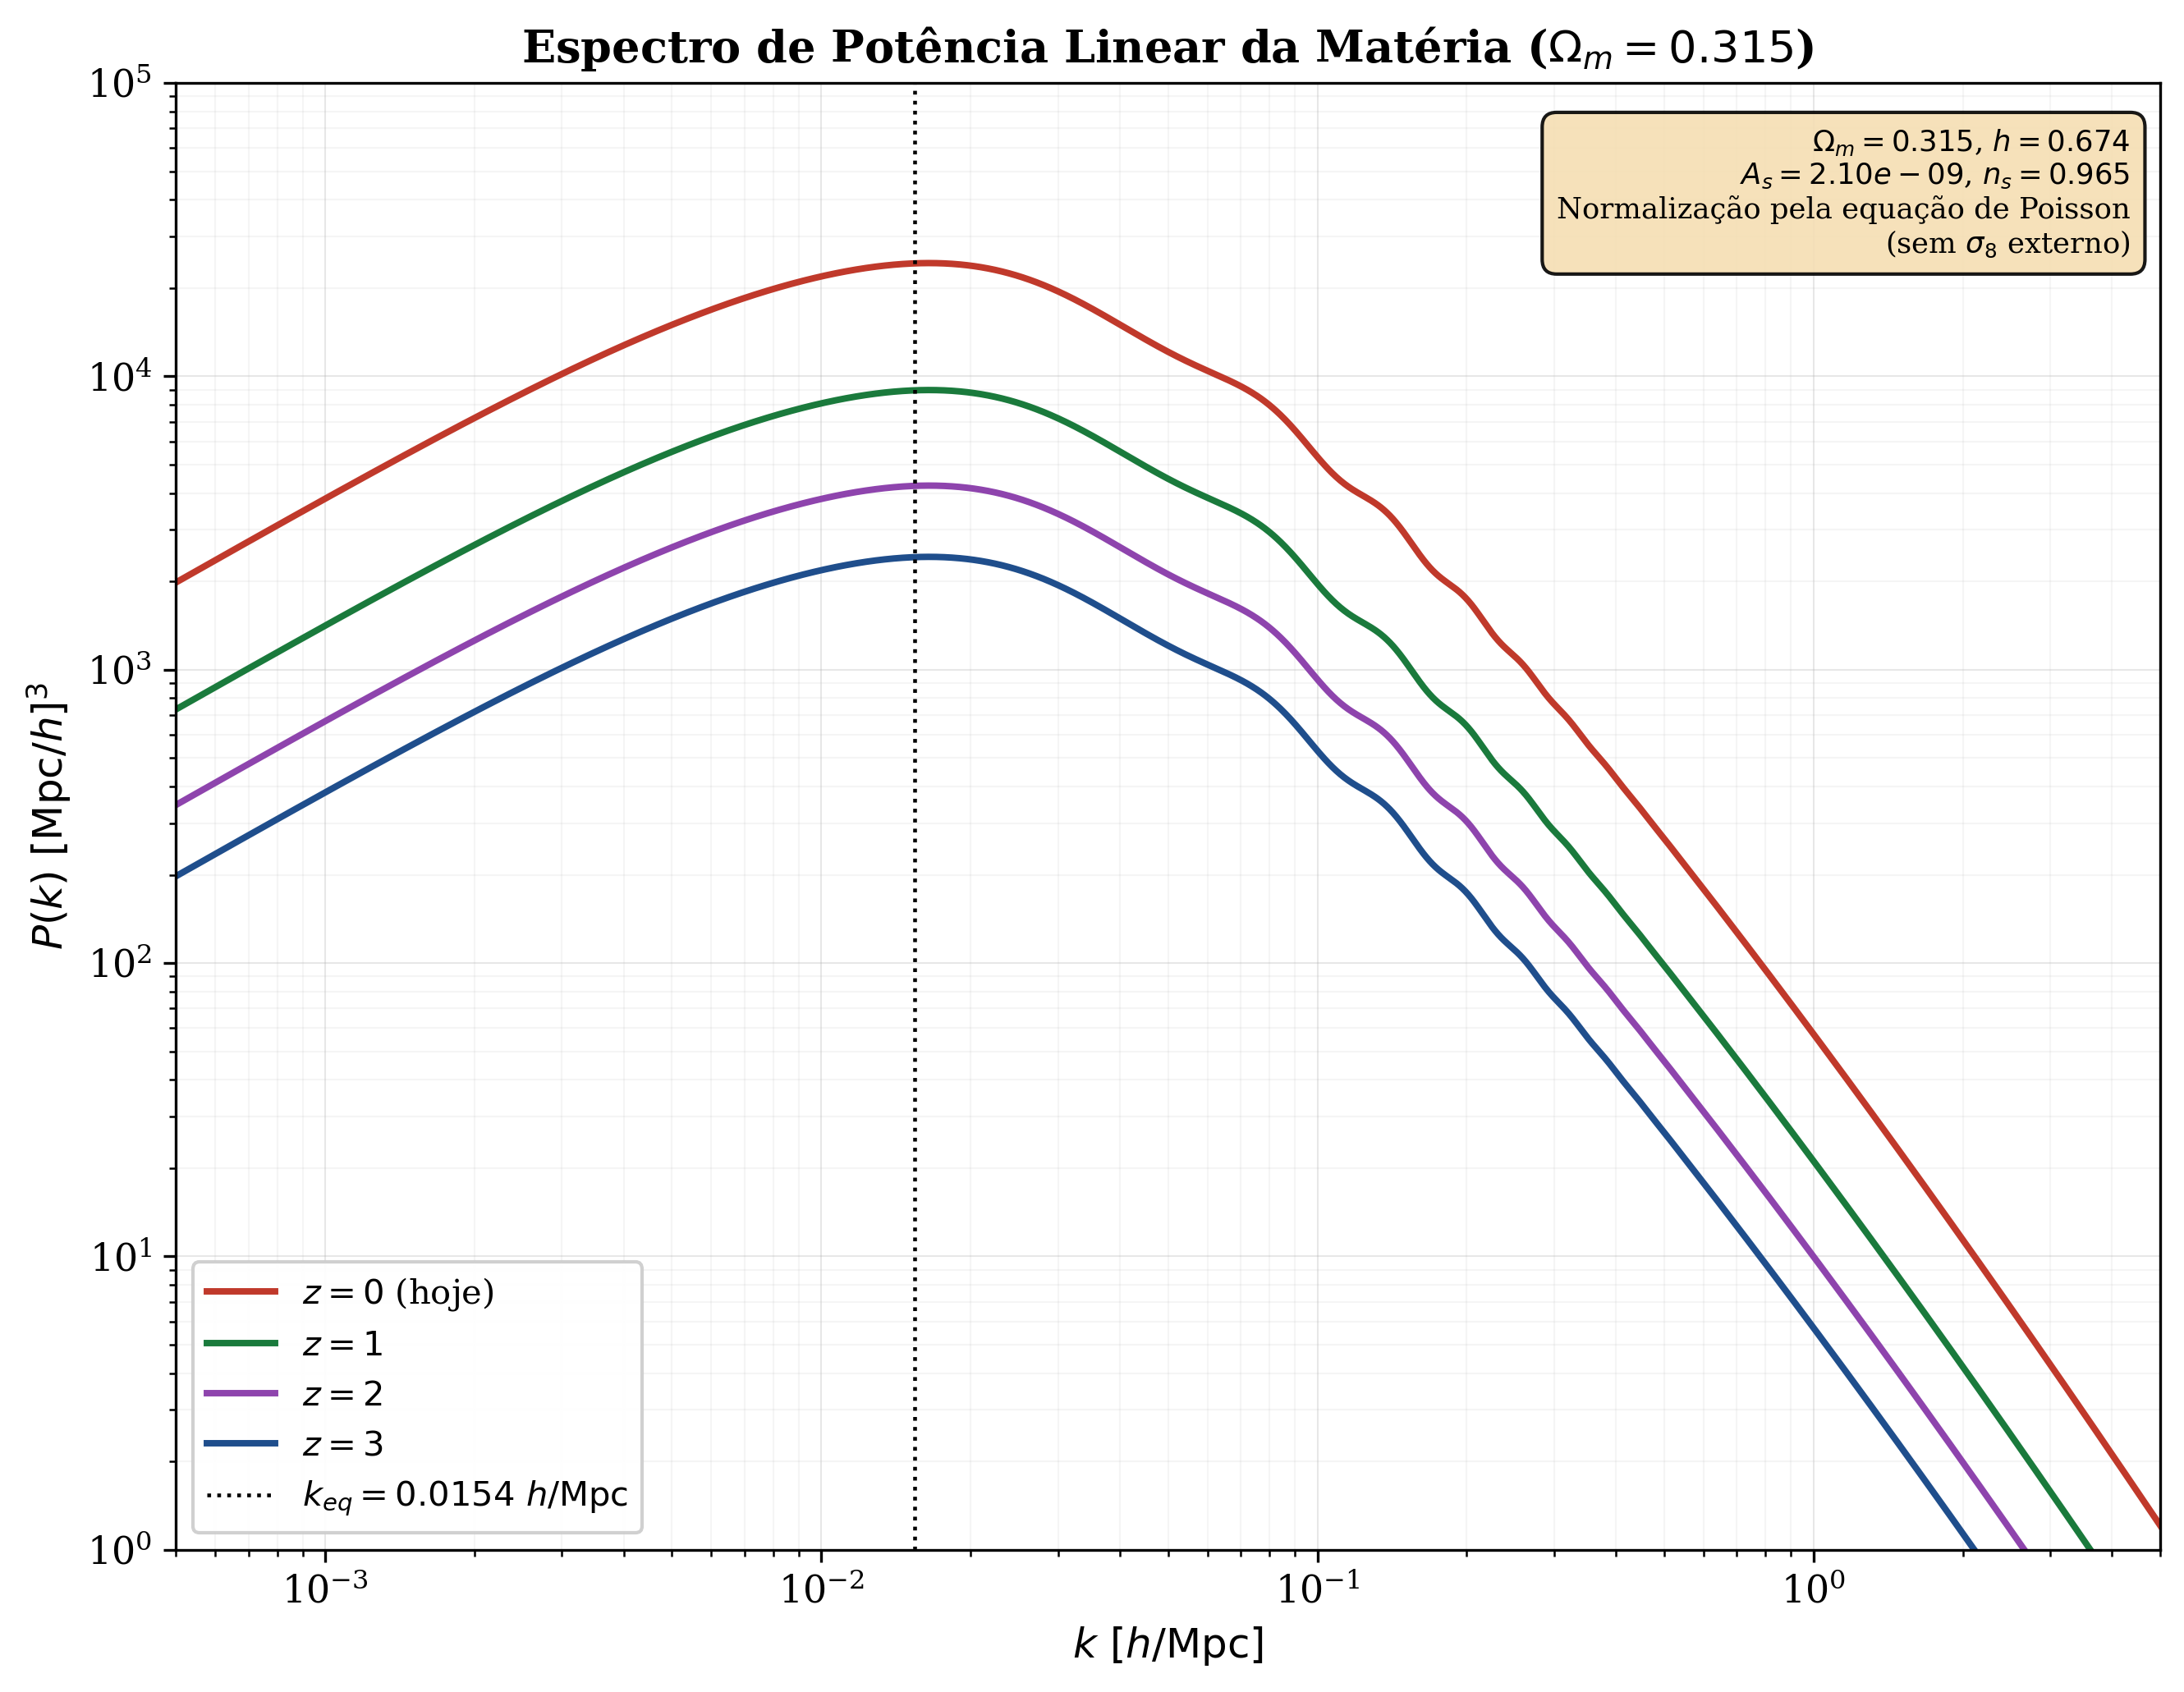

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# CONFIGURACOES DE ESTILO
# =============================================================================

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.9,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '-',
    'grid.linewidth': 0.5
})


# =============================================================================
# PARAMETROS COSMOLOGICOS - Planck 2018
# =============================================================================

Omega_b_h2 = 0.0224
Omega_m = 0.315
Omega_Lambda = 0.685
h = 0.674

c_luz = 299792.458
H0_Mpc = 100 * h / c_luz


# Espectro primordial
A_s = 2.1e-9
n_s = 0.965
k_pivot = 0.05


# Igualdade materia-radiacao
z_eq = 3400


# Parametros auxiliares
omega_m = Omega_m * h**2
omega_b = Omega_b_h2

Theta27 = 2.7255 / 2.7


# Redshifts considerados
z_values = [0, 1, 2, 3]

z_labels = [
    '$z=0$ (hoje)',
    '$z=1$',
    '$z=2$',
    '$z=3$'
]

z_colors = [
    '#c0392b',
    '#1a7a3c',
    '#8e44ad',
    '#1f4e8c'
]


print("=" * 68)
print("GRAFICO 8: ESPECTRO DE POTENCIA LINEAR DA MATERIA P(k)")
print("=" * 68)


# =============================================================================
# ESCALA DE IGUALDADE MATERIA-RADIACAO
#
# Definicao:
#
# k_eq = a_eq * H(a_eq)
#
# com
#
# a_eq = 1 / (1 + z_eq)
# =============================================================================

a_eq = 1.0 / (1.0 + z_eq)

k_eq_Mpc = (
    H0_Mpc
    * np.sqrt(
        2.0
        * Omega_m
        * (1.0 + z_eq)
    )
)

k_eq_hMpc = k_eq_Mpc / h


print(
    f"k_eq = {k_eq_Mpc:.5f} Mpc^-1"
    f" = {k_eq_hMpc:.5f} h/Mpc"
)


# =============================================================================
# FATOR DE CRESCIMENTO
#
# D_+(z) = g(z) / (1 + z)
#
# A normalizacao adotada corresponde ao regime de dominacao
# da materia, sem dividir por D_+(0).
# =============================================================================

def D_plus(z):
    """
    Fator de crescimento linear normalizado
    no regime de dominacao da materia.
    """

    E2 = (
        Omega_m * (1 + z)**3
        + Omega_Lambda
    )

    Omega_m_z = (
        Omega_m * (1 + z)**3
        / E2
    )

    Omega_Lambda_z = (
        Omega_Lambda
        / E2
    )

    growth = (
        2.5 * Omega_m_z
        / (
            Omega_m_z**(4.0 / 7.0)
            - Omega_Lambda_z
            + (
                1
                + Omega_m_z / 2.0
            )
            * (
                1
                + Omega_Lambda_z / 70.0
            )
        )
    )

    return growth / (1 + z)


print(
    "\nFator de crescimento D_plus(z):"
)

for z in z_values:

    growth = D_plus(z)

    growth_relative = (
        growth
        / D_plus(0)
    )

    print(
        f"  z = {z}: "
        f"D_plus(z) = {growth:.4f}   "
        f"[D_plus(z)/D_plus(0) = "
        f"{growth_relative:.4f}]"
    )


# =============================================================================
# FUNCAO DE TRANSFERENCIA
#
# Parametrizacao de Eisenstein & Hu (1998).
# =============================================================================

def eh98_auxiliary_quantities(
    omega_m,
    omega_b,
    Theta27
):
    """
    Calcula as quantidades auxiliares da parametrizacao
    de Eisenstein & Hu (1998).
    """

    z_eq_eh = (
        2.5e4
        * omega_m
        * Theta27**(-4)
    )

    k_eq_eh = (
        7.46e-2
        * omega_m
        * Theta27**(-2)
    )


    b1 = (
        0.313
        * omega_m**(-0.419)
        * (
            1
            + 0.607 * omega_m**0.674
        )
    )

    b2 = (
        0.238
        * omega_m**0.223
    )


    z_drag = (
        1291
        * omega_m**0.251
        / (
            1
            + 0.659 * omega_m**0.828
        )
        * (
            1
            + b1 * omega_b**b2
        )
    )


    R_eq = (
        31.5
        * omega_b
        * Theta27**(-4)
        * (
            z_eq_eh / 1e3
        )**(-1)
    )

    R_drag = (
        31.5
        * omega_b
        * Theta27**(-4)
        * (
            z_drag / 1e3
        )**(-1)
    )


    sound_horizon = (
        2.0
        / (
            3.0 * k_eq_eh
        )
        * np.sqrt(
            6.0 / R_eq
        )
        * np.log(
            (
                np.sqrt(1 + R_drag)
                + np.sqrt(
                    R_drag + R_eq
                )
            )
            / (
                1
                + np.sqrt(R_eq)
            )
        )
    )


    k_silk = (
        1.6
        * omega_b**0.52
        * omega_m**0.73
        * (
            1
            + (
                10.4 * omega_m
            )**(-0.95)
        )
    )


    a1 = (
        (46.9 * omega_m)**0.670
        * (
            1
            + (
                32.1 * omega_m
            )**(-0.532)
        )
    )

    a2 = (
        (12.0 * omega_m)**0.424
        * (
            1
            + (
                45.0 * omega_m
            )**(-0.582)
        )
    )


    alpha_c = (
        a1**(-omega_b / omega_m)
        * a2**(
            -(omega_b / omega_m)**3
        )
    )


    b1c = (
        0.944
        / (
            1
            + (
                458 * omega_m
            )**(-0.708)
        )
    )

    b2c = (
        0.395 * omega_m
    )**(-0.0266)


    omega_c = omega_m - omega_b

    beta_c = (
        1.0
        / (
            1
            + b1c
            * (
                (
                    omega_c
                    / omega_m
                )**b2c
                - 1
            )
        )
    )


    y = (
        1
        + z_eq_eh
    ) / (
        1
        + z_drag
    )


    G_y = (
        y
        * (
            -6 * np.sqrt(1 + y)
            + (
                2
                + 3 * y
            )
            * np.log(
                (
                    np.sqrt(1 + y)
                    + 1
                )
                / (
                    np.sqrt(1 + y)
                    - 1
                )
            )
        )
    )


    alpha_b = (
        2.07
        * k_eq_eh
        * sound_horizon
        * (1 + R_drag)**(-0.75)
        * G_y
    )


    beta_node = (
        8.41
        * omega_m**0.435
    )


    beta_b = (
        0.5
        + omega_b / omega_m
        + (
            3
            - 2 * omega_b / omega_m
        )
        * np.sqrt(
            (
                17.2 * omega_m
            )**2
            + 1
        )
    )


    return {
        'z_eq': z_eq_eh,
        'k_eq': k_eq_eh,
        'z_drag': z_drag,
        's': sound_horizon,
        'k_silk': k_silk,
        'alpha_c': alpha_c,
        'beta_c': beta_c,
        'alpha_b': alpha_b,
        'beta_b': beta_b,
        'beta_node': beta_node
    }


# =============================================================================
# FUNCAO AUXILIAR T0
# =============================================================================

def T0_tilde(q, a_c, b_c):
    """
    Funcao auxiliar utilizada na funcao de transferencia.
    """

    C = (
        14.2 / a_c
        + 386.0
        / (
            1
            + 69.9 * q**1.08
        )
    )

    L = np.log(
        np.e
        + 1.8 * b_c * q
    )

    return L / (
        L
        + C * q**2
    )


# =============================================================================
# FUNCAO DE TRANSFERENCIA COMPLETA
# =============================================================================

def T_k_full_EH98(
    k,
    params,
    omega_m,
    omega_b
):
    """
    Funcao de transferencia completa de Eisenstein & Hu,
    incluindo as contribuicoes bariônica e de materia escura.
    """

    q = (
        k
        / (
            13.41
            * params['k_eq']
        )
    )


    # Componente de materia escura
    f = (
        1.0
        / (
            1
            + (
                k * params['s'] / 5.4
            )**4
        )
    )


    T_c = (
        f
        * T0_tilde(
            q,
            1.0,
            1.0 / params['beta_c']
        )
        + (
            1 - f
        )
        * T0_tilde(
            q,
            params['alpha_c'],
            1.0 / params['beta_c']
        )
    )


    # Componente bariônica
    s_tilde = (
        params['s']
        / (
            1
            + (
                params['beta_node']
                / (
                    k * params['s']
                )
            )**3
        )**(1.0 / 3.0)
    )


    # np.sinc usa a convencao sin(pi*x)/(pi*x)
    j0 = np.sinc(
        k * s_tilde / np.pi
    )


    T_b = (
        T0_tilde(
            q,
            1.0,
            1.0
        )
        / (
            1
            + (
                k * params['s'] / 5.2
            )**2
        )
        + (
            params['alpha_b']
            / (
                1
                + (
                    params['beta_b']
                    / (
                        k * params['s']
                    )
                )**3
            )
        )
        * np.exp(
            -(
                k / params['k_silk']
            )**1.4
        )
    ) * j0


    # Soma ponderada das duas componentes
    omega_c = omega_m - omega_b

    return (
        (omega_b / omega_m) * T_b
        + (omega_c / omega_m) * T_c
    )


params = eh98_auxiliary_quantities(
    omega_m,
    omega_b,
    Theta27
)


# Normalizacao da funcao de transferencia
k_reference = np.array([1e-6])

T_reference = T_k_full_EH98(
    k_reference,
    params,
    omega_m,
    omega_b
)[0]


def T_k(k_Mpc):
    """
    Funcao de transferencia normalizada.
    """

    k_array = np.asarray(
        k_Mpc,
        dtype=float
    )

    return (
        T_k_full_EH98(
            k_array,
            params,
            omega_m,
            omega_b
        )
        / T_reference
    )


print(
    f"\nHorizonte sonico no arrasto = "
    f"{params['s']:.2f} Mpc"
)

print(
    f"Redshift do arrasto z_d = "
    f"{params['z_drag']:.1f}"
)

print(
    f"Escala de Silk k_silk = "
    f"{params['k_silk']:.4f} Mpc^-1"
)


# =============================================================================
# ESPECTRO DE POTENCIA
#
# A normalizacao e obtida diretamente da equacao de Poisson
# e do espectro primordial de curvatura.
# =============================================================================

C_poisson = (
    8 * np.pi**2 / 25
    * (
        A_s
        / (
            Omega_m**2
            * H0_Mpc**4
        )
    )
    * k_pivot**(
        1 - n_s
    )
)


def P_k_physical_Mpc3(
    k_Mpc,
    z
):
    """
    Espectro de potencia da materia em Mpc^3.
    """

    k_array = np.asarray(
        k_Mpc,
        dtype=float
    )

    return (
        C_poisson
        * k_array**n_s
        * T_k(k_array)**2
        * D_plus(z)**2
    )


# =============================================================================
# GRADE DE NUMERO DE ONDA
#
# A funcao e calculada inicialmente em Mpc^-1
# e depois convertida para a convencao h/Mpc.
# =============================================================================

k_min_hMpc = 5e-4
k_max_hMpc = 5.0

k_hMpc = np.logspace(
    np.log10(k_min_hMpc),
    np.log10(k_max_hMpc),
    2000
)


# Conversao para Mpc^-1
k_Mpc = k_hMpc * h


# Calcula P(k) para cada redshift
P_vals_hMpc3 = []


for z in z_values:

    P_Mpc3 = P_k_physical_Mpc3(
        k_Mpc,
        z
    )

    # Conversao de Mpc^3 para (Mpc/h)^3
    P_hMpc3 = (
        P_Mpc3
        * h**3
    )

    P_vals_hMpc3.append(
        P_hMpc3
    )


# =============================================================================
# VERIFICACAO DO PICO
# =============================================================================

print(
    "\nVerificacao da amplitude e "
    "localizacao do pico (z = 0):"
)


idx_peak = np.argmax(
    P_vals_hMpc3[0]
)


peak_k = k_hMpc[idx_peak]
peak_P = P_vals_hMpc3[0][idx_peak]


print(
    f"  Pico em k = {peak_k:.4f} h/Mpc"
)

print(
    f"  P(k) = {peak_P:.3e} (Mpc/h)^3"
)

print(
    "  Referencia da literatura: "
    "pico da ordem de 3e4 (Mpc/h)^3 "
    "em k da ordem de 0.01-0.02 h/Mpc"
)


# =============================================================================
# GRAFICO
# =============================================================================

fig, ax = plt.subplots(
    figsize=(9, 7)
)


for z, label, color, P in zip(
    z_values,
    z_labels,
    z_colors,
    P_vals_hMpc3
):

    ax.plot(
        k_hMpc,
        P,
        color=color,
        linewidth=1.9,
        label=label
    )


# Escala de igualdade materia-radiacao
ax.axvline(
    k_eq_hMpc,
    color='black',
    linestyle=':',
    linewidth=1.1,
    label=(
        rf'$k_{{eq}} = '
        rf'{k_eq_hMpc:.4f}\ '
        rf'h/\mathrm{{Mpc}}$'
    )
)


# =============================================================================
# ESCALAS DOS EIXOS
# =============================================================================

ax.set_xscale('log')
ax.set_yscale('log')


ax.set_xlim(
    k_min_hMpc,
    k_max_hMpc
)

ax.set_ylim(
    1e0,
    1e5
)


ax.set_xlabel(
    r'$k\ [h/\mathrm{Mpc}]$'
)


ax.set_ylabel(
    r'$P(k)\ [\mathrm{Mpc}/h]^3$'
)


ax.set_title(
    rf'Espectro de Potência Linear da Matéria '
    rf'($\Omega_m={Omega_m}$)',
    fontweight='bold'
)


ax.legend(
    loc='lower left',
    fontsize=10,
    framealpha=0.92
)


# =============================================================================
# GRADE
# =============================================================================

ax.grid(
    True,
    which='major',
    alpha=0.3
)

ax.grid(
    True,
    which='minor',
    alpha=0.12
)


# =============================================================================
# INFORMACOES NO GRAFICO
# =============================================================================

info_text = (
    rf'$\Omega_m={Omega_m:.3f}$, '
    rf'$h={h:.3f}$'
    '\n'
    rf'$A_s={A_s:.2e}$, '
    rf'$n_s={n_s:.3f}$'
    '\n'
    r'Normalização pela equação de Poisson'
    '\n'
    r'(sem $\sigma_8$ externo)'
)


ax.text(
    0.985,
    0.97,
    info_text,
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    fontsize=8.5,
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.9,
        pad=0.5
    )
)


# =============================================================================
# SALVAMENTO
# =============================================================================

plt.tight_layout()


plt.savefig(
    'grafico8_Pk_fisico.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'grafico8_Pk_fisico.pdf',
    dpi=300,
    bbox_inches='tight'
)


print("\nGrafico 8 gerado com sucesso.")
print("Arquivos salvos:")
print("  - grafico8_Pk_fisico.png")
print("  - grafico8_Pk_fisico.pdf")

print("=" * 68)


plt.show()